# Base 4 — temperatura em Jena:

In [1]:
from pathlib import Path
import hashlib
import json
import math
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL


def find_project_root(start):
    for candidate in (start, *start.parents):
        if ((candidate / 'projeto.yaml').is_file() or
                (candidate / 'config' / 'projeto.yaml').is_file()):
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())

In [2]:
def _inteiros_positivos(valores, nome):
    resultado = tuple(dict.fromkeys(valores))
    if any(not isinstance(valor, (int, np.integer)) or valor <= 0 for valor in resultado):
        raise ValueError(f'{nome} deve conter somente inteiros positivos.')
    return resultado


def _validar_grade(dados, *, time_col, expected_step):
    if expected_step <= pd.Timedelta(0):
        raise ValueError('expected_step deve ser positivo.')
    quadro = dados.copy()
    quadro[time_col] = pd.to_datetime(quadro[time_col], errors='raise')
    if quadro[time_col].isna().any():
        raise ValueError('A coluna temporal cont?m valores ausentes.')
    if quadro[time_col].duplicated().any():
        raise ValueError('A coluna temporal cont?m timestamps duplicados.')
    if not quadro[time_col].is_monotonic_increasing:
        raise ValueError('Os dados devem estar em ordem temporal crescente.')
    if not quadro[time_col].diff().dropna().eq(expected_step).all():
        raise ValueError(
            'A grade temporal deve ser regular antes da cria??o de features; '
            'preserve lacunas como linhas expl?citas.'
        )
    return quadro


def build_one_step_frame(
    dados, *, time_col, target_col, external_cols=(), expected_step,
    lags=(), windows=(), availability=None,
):
    external_cols = tuple(dict.fromkeys(external_cols))
    required = {time_col, target_col, *external_cols}
    missing = sorted(required.difference(dados.columns))
    if missing:
        raise KeyError(f'Colunas ausentes: {missing}')
    if target_col in external_cols:
        raise ValueError('O alvo n?o pode ser declarado como covari?vel.')

    step = pd.Timedelta(expected_step)
    lags = _inteiros_positivos(lags, 'lags')
    windows = _inteiros_positivos(windows, 'windows')
    quadro = _validar_grade(dados, time_col=time_col, expected_step=step)
    regras = dict(availability or {})
    desconhecidas = sorted(set(regras).difference(external_cols))
    if desconhecidas:
        raise KeyError(f'Regras para covari?veis n?o declaradas: {desconhecidas}')

    saida = pd.DataFrame(index=quadro.index)
    saida['origin_time'] = quadro[time_col]
    saida['target_time'] = quadro[time_col].shift(-1)
    saida['level_t'] = quadro[target_col]
    saida['y_true'] = quadro[target_col].shift(-1)
    saida['target_delta'] = saida['y_true'] - saida['level_t']
    features = ['level_t']

    for coluna in external_cols:
        disponibilidade, atraso = regras.get(coluna, ('na_origem', 0))
        if disponibilidade == 'proibida':
            raise ValueError(f'A covari?vel {coluna!r} foi classificada como proibida.')
        if disponibilidade == 'conhecido_antecipadamente':
            nome = f'{coluna}_alvo'
            saida[nome] = quadro[coluna].shift(-1)
        else:
            nome = f'{coluna}_t' if atraso == 0 else f'{coluna}_lag_{atraso}'
            saida[nome] = quadro[coluna].shift(atraso)
        features.append(nome)

    for lag in lags:
        nome = f'target_lag_{lag}'
        saida[nome] = quadro[target_col].shift(lag)
        features.append(nome)

    historico_anterior = quadro[target_col].shift(1)
    for janela in windows:
        rolling = historico_anterior.rolling(janela, min_periods=janela)
        media, desvio = f'target_mean_{janela}', f'target_std_{janela}'
        saida[media] = rolling.mean()
        saida[desvio] = rolling.std(ddof=0)
        features.extend([media, desvio])

    alvo_data = saida['target_time']
    ciclos = (
        ('hour', alvo_data.dt.hour, 24),
        ('dow', alvo_data.dt.dayofweek, 7),
        ('month', alvo_data.dt.month - 1, 12),
    )
    for rotulo, valor, periodo in ciclos:
        seno, cosseno = f'target_{rotulo}_sin', f'target_{rotulo}_cos'
        angulo = 2 * np.pi * valor / periodo
        saida[seno] = np.sin(angulo)
        saida[cosseno] = np.cos(angulo)
        features.extend([seno, cosseno])

    par_de_um_passo = saida['target_time'].sub(saida['origin_time']).eq(step)
    obrigatorias = ['origin_time', 'target_time', 'y_true', 'target_delta', *features]
    saida = saida.loc[par_de_um_passo].dropna(subset=obrigatorias)
    return saida.reset_index(drop=True), features


def chronological_train_test(quadro, train_ratio):
    if not 0 < train_ratio < 1:
        raise ValueError('train_ratio deve estar estritamente entre 0 e 1.')
    if not {'origin_time', 'target_time'}.issubset(quadro):
        raise KeyError('O quadro deve conter origin_time e target_time.')
    if len(quadro) < 3:
        raise ValueError('S?o necess?rias ao menos tr?s amostras para o corte.')
    if not quadro['origin_time'].is_monotonic_increasing:
        raise ValueError('O quadro deve estar em ordem temporal crescente.')
    corte = int(len(quadro) * train_ratio)
    if corte <= 0 or corte >= len(quadro):
        raise ValueError('O corte solicitado produz treino ou teste vazio.')
    inicio_teste = quadro.iloc[corte]['origin_time']
    treino = quadro.iloc[:corte]
    treino = treino.loc[treino['target_time'] < inicio_teste]
    teste = quadro.iloc[corte:]
    if treino.empty or teste.empty:
        raise ValueError('A purga temporal produziu treino ou teste vazio.')
    return treino.reset_index(drop=True), teste.reset_index(drop=True)


def longest_observed_run(serie, minimum_length=1):
    if minimum_length < 1:
        raise ValueError('minimum_length deve ser positivo.')
    observado = serie.notna()
    if not observado.any():
        raise ValueError('A s?rie n?o possui valores observados.')
    grupos = observado.ne(observado.shift(fill_value=False)).cumsum()
    trecho = max((grupo for _, grupo in serie.loc[observado].groupby(grupos.loc[observado])), key=len)
    if len(trecho) < minimum_length:
        raise ValueError(
            f'O maior trecho observado tem {len(trecho)} linhas; '
            f's?o necess?rias {minimum_length}.'
        )
    return trecho


def purged_time_series_splits(origin_time, target_time, *, n_splits=3):
    origens = pd.Series(pd.to_datetime(origin_time, errors='raise')).reset_index(drop=True)
    alvos = pd.Series(pd.to_datetime(target_time, errors='raise')).reset_index(drop=True)
    if len(origens) != len(alvos):
        raise ValueError('origin_time e target_time devem ter o mesmo tamanho.')
    if n_splits < 1 or len(origens) < n_splits + 1:
        raise ValueError('H? poucas amostras para o n?mero de dobras solicitado.')
    if origens.isna().any() or alvos.isna().any():
        raise ValueError('Datas de origem e alvo n?o podem ser ausentes.')
    if not origens.is_monotonic_increasing or not alvos.gt(origens).all():
        raise ValueError('As datas devem estar ordenadas e cada alvo deve suceder sua origem.')
    tamanho_validacao = len(origens) // (n_splits + 1)
    if tamanho_validacao == 0:
        raise ValueError('As dobras de valida??o ficariam vazias.')
    splits = []
    for dobra in range(n_splits):
        inicio = len(origens) - (n_splits - dobra) * tamanho_validacao
        fim = len(origens) if dobra == n_splits - 1 else inicio + tamanho_validacao
        validacao = np.arange(inicio, fim, dtype=int)
        primeira_origem = origens.iloc[inicio]
        ajuste = np.flatnonzero((np.arange(len(origens)) < inicio) & (alvos < primeira_origem))
        if len(ajuste) == 0 or len(validacao) == 0:
            raise ValueError('A purga produziu uma dobra vazia.')
        splits.append((ajuste, validacao))
    return splits


def validar_proibidas(colunas_usadas, proibidas, base_id):
    conflito = sorted(set(colunas_usadas).intersection(proibidas))
    if conflito:
        raise ValueError(f'Colunas proibidas em uso na {base_id}: {conflito}')


def preparar_entrada_base2(dados):
    if 'holiday' not in dados.columns:
        raise KeyError('A Base 2 exige a coluna holiday para derivar is_holiday.')
    quadro = dados.copy()
    quadro['is_holiday'] = quadro['holiday'].notna().astype(int)
    return quadro


BASE_NUMBER = 4
BASE_ID = 'base_04'
BASE_DIR = ROOT / 'data' / 'base_04'
DATA_PATH = BASE_DIR / 'prepared.csv'
TIME_COL = 'Date Time'
TARGET_COL = 'T (degC)'
EXTERNAL_COLS = [
    'p (mbar)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)',
    'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)',
    'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd_sin', 'wd_cos',
]
PROHIBITED_COLS = ('wd (deg)',)
EXPECTED_STEP = pd.Timedelta('10min')
FREQUENCY = '10min'
TRAIN_RATIO = 0.8
LAGS = [1, 2, 6, 12, 144, 1008]
WINDOWS = [6, 144, 1008]
AVAILABILITY = {coluna: ('na_origem', 0) for coluna in EXTERNAL_COLS}
STL_PERIODS = {'di?ria (144 pontos)': 144, 'semanal (1008 pontos)': 1008}
STL_ROBUST = False
ACF_LAGS = 288
LJUNG_LAGS = [1, 6, 144, 288]
TUNING_MAX_ROWS = 60000
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Limpeza e preparação reutilizadas

In [3]:
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = pd.read_csv(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='raise')
df = df.sort_values(TIME_COL, kind='stable').reset_index(drop=True)
assert df[TIME_COL].is_monotonic_increasing and df[TIME_COL].is_unique
audit = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'inicio': df[TIME_COL].min(), 'fim': df[TIME_COL].max(),
    'nulos_alvo': int(df[TARGET_COL].isna().sum()),
    'timestamps_duplicados': int(df[TIME_COL].duplicated().sum()),
}, name='valor').to_frame()
display(audit)
display(df.head())

,valor
arquivo,data\base_04\prepared.csv
sha256,4e3a2361cd6c686a68162e57baa1907466a59866a4026d...
linhas,420768
colunas,24
inicio,2009-01-01 00:10:00
fim,2017-01-01 00:00:00
nulos_alvo,544
timestamps_duplicados,0


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,wd (deg),hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos,wd_sin,wd_cos
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,...,152.3,0,3,1,0.043619,0.999048,0.5,0.866025,0.464842,-0.885394
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,...,136.1,0,3,1,0.087156,0.996195,0.5,0.866025,0.693402,-0.720551
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,...,171.6,0,3,1,0.130526,0.991445,0.5,0.866025,0.146083,-0.989272
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,...,198.0,0,3,1,0.173648,0.984808,0.5,0.866025,-0.309017,-0.951057
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,...,214.3,0,3,1,0.216440,0.976296,0.5,0.866025,-0.563526,-0.826098


## 2. Gráficos exploratórios

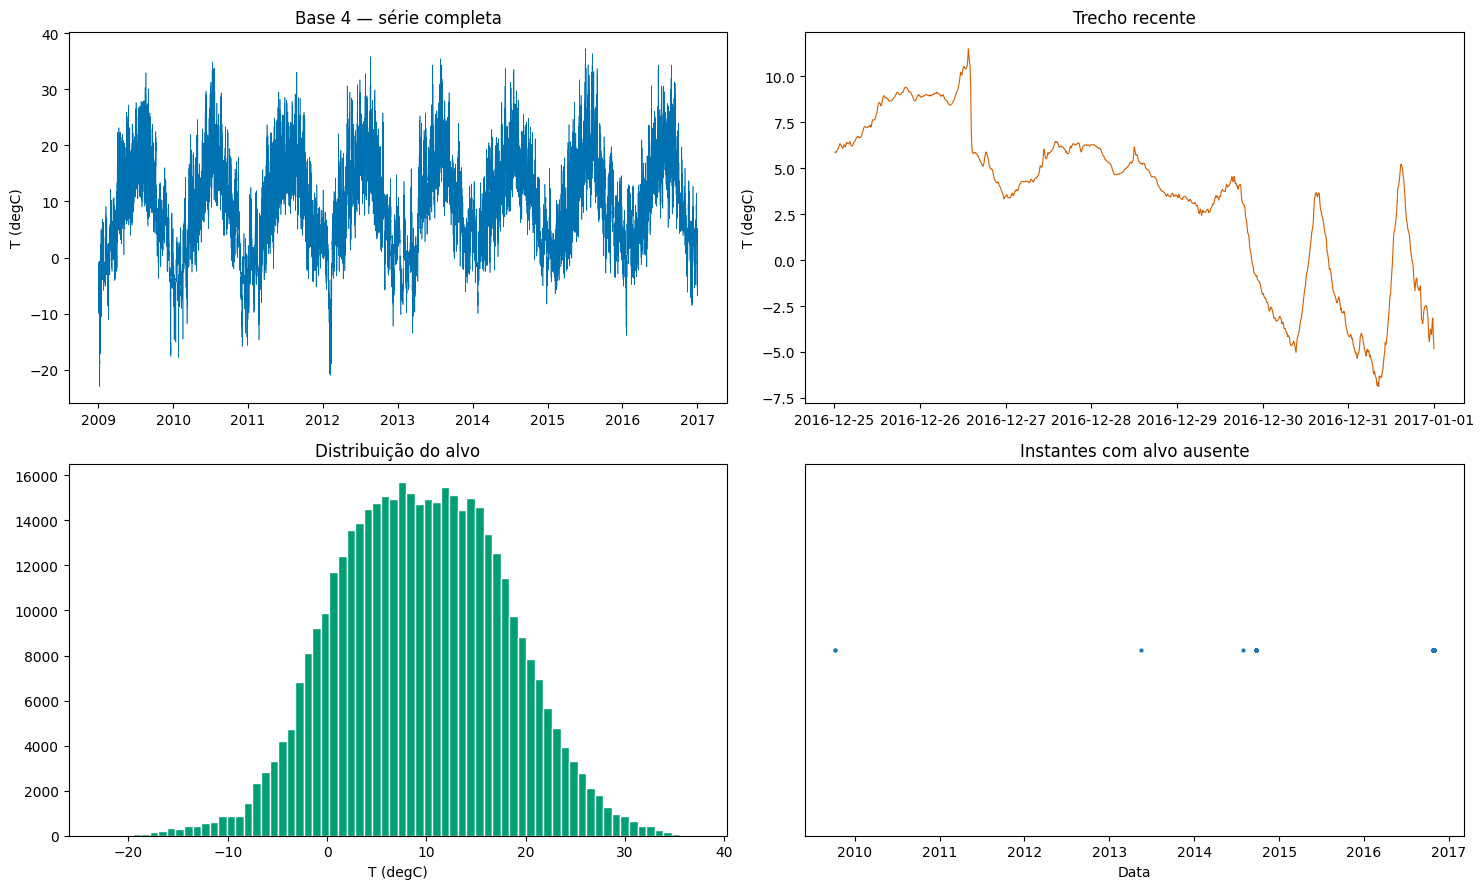

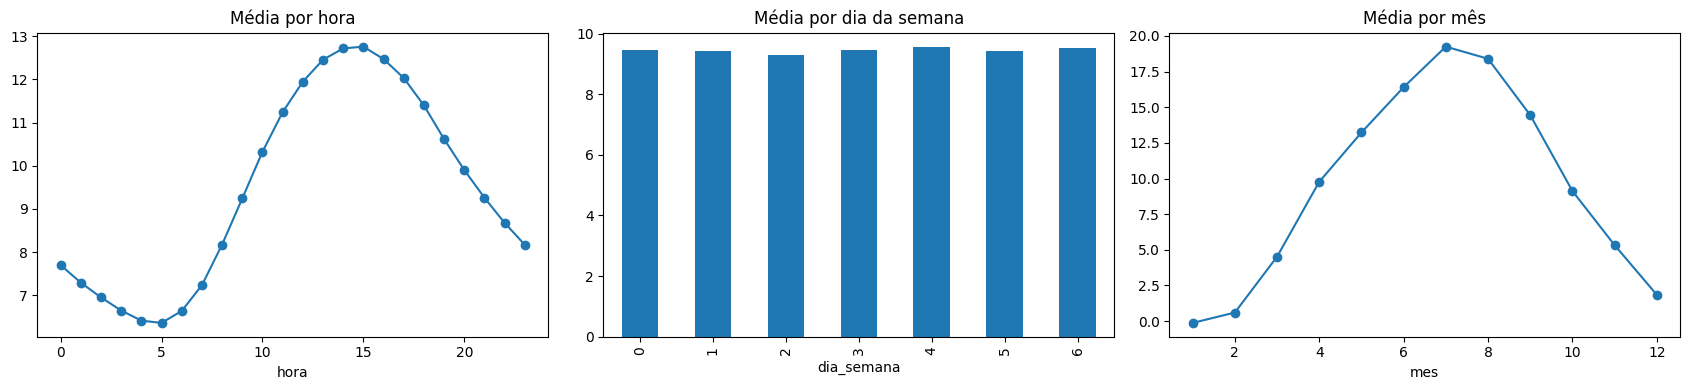

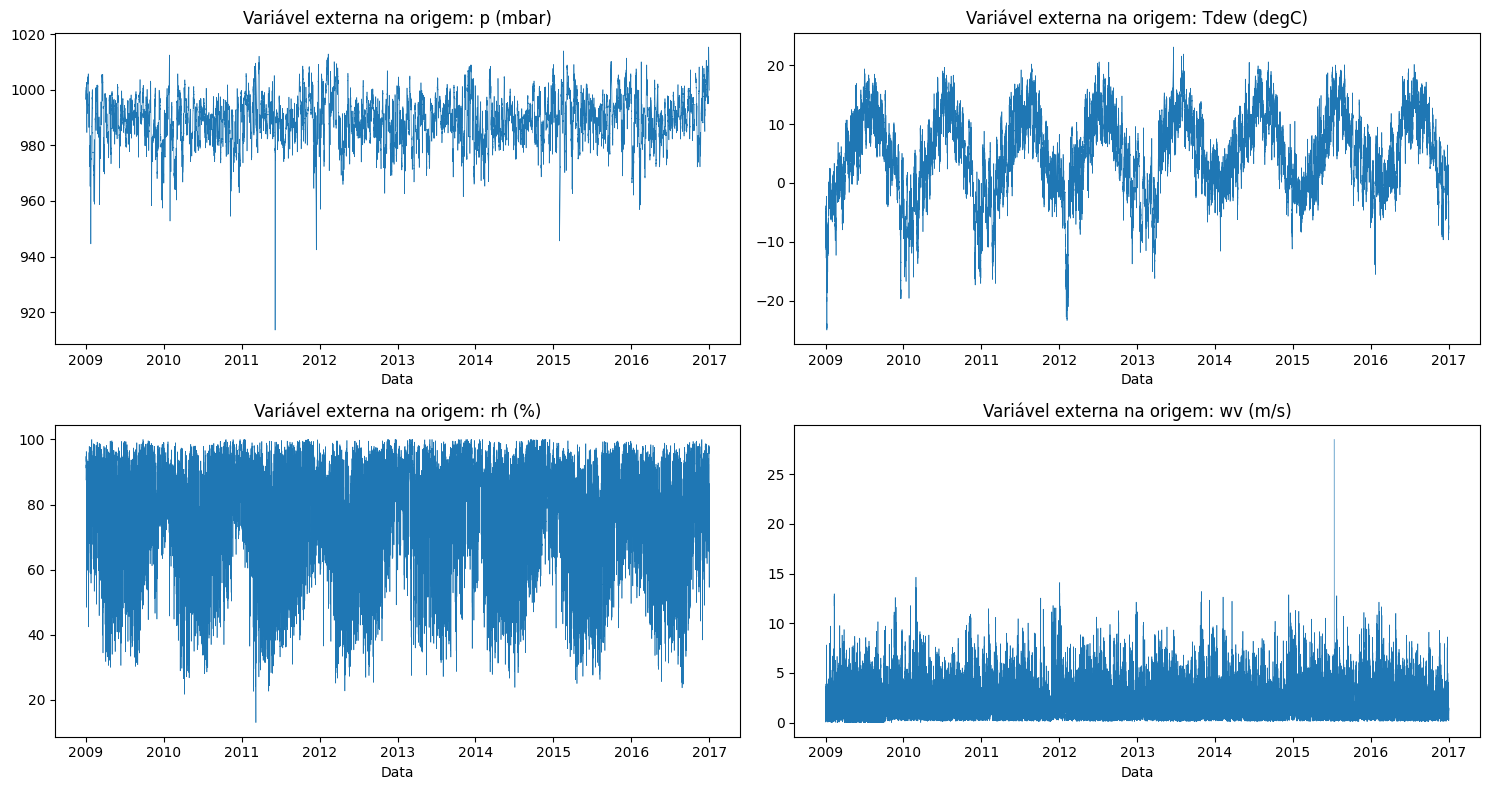

In [4]:
observed = df.dropna(subset=[TARGET_COL]).copy()
recent = observed.tail(1008)
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes[0, 0].plot(observed[TIME_COL], observed[TARGET_COL], lw=.45, color='#0072b2')
axes[0, 0].set(title=f'Base {BASE_NUMBER} — série completa', ylabel=TARGET_COL)
axes[0, 1].plot(recent[TIME_COL], recent[TARGET_COL], lw=.8, color='#d55e00')
axes[0, 1].set(title='Trecho recente', ylabel=TARGET_COL)
axes[1, 0].hist(observed[TARGET_COL], bins=70, edgecolor='white', color='#009e73')
axes[1, 0].set(title='Distribuição do alvo', xlabel=TARGET_COL)
axes[1, 1].scatter(df.loc[df[TARGET_COL].isna(), TIME_COL], np.ones(df[TARGET_COL].isna().sum()), s=4)
axes[1, 1].set(title='Instantes com alvo ausente', xlabel='Data', yticks=[])
plt.tight_layout(); plt.show()

calendar = observed.assign(
    hora=observed[TIME_COL].dt.hour,
    dia_semana=observed[TIME_COL].dt.dayofweek,
    mes=observed[TIME_COL].dt.month,
)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
calendar.groupby('hora')[TARGET_COL].mean().plot(ax=axes[0], marker='o', title='Média por hora')
calendar.groupby('dia_semana')[TARGET_COL].mean().plot.bar(ax=axes[1], title='Média por dia da semana')
calendar.groupby('mes')[TARGET_COL].mean().plot(ax=axes[2], marker='o', title='Média por mês')
plt.tight_layout(); plt.show()

external_to_plot = ['p (mbar)', 'Tdew (degC)', 'rh (%)', 'wv (m/s)']
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, column in zip(axes.flat, external_to_plot, strict=True):
    ax.plot(df[TIME_COL], df[column], lw=.45)
    ax.set(title=f'Variável externa na origem: {column}', xlabel='Data')
plt.tight_layout(); plt.show()

## 3. STL e força da sazonalidade

A STL usa somente a janela cronológica de treino e o maior trecho
contínuo sem ausências. Não há interpolação do alvo. Isso evita criar
ciclos artificiais em lacunas longas. A força é
`max(0, 1 - Var(R) / Var(S + R))`.

,periodo,observacoes_por_ciclo,forca_sazonalidade,forca_tendencia,ausencias_no_treino_nao_interpoladas,pontos_no_trecho_continuo,inicio_trecho,fim_trecho
0,di?ria (144 pontos),144,0.859574,0.983570,99,189497,2009-10-08 10:10:00,2013-05-16 08:50:00
1,semanal (1008 pontos),1008,0.610709,0.919162,99,189497,2009-10-08 10:10:00,2013-05-16 08:50:00


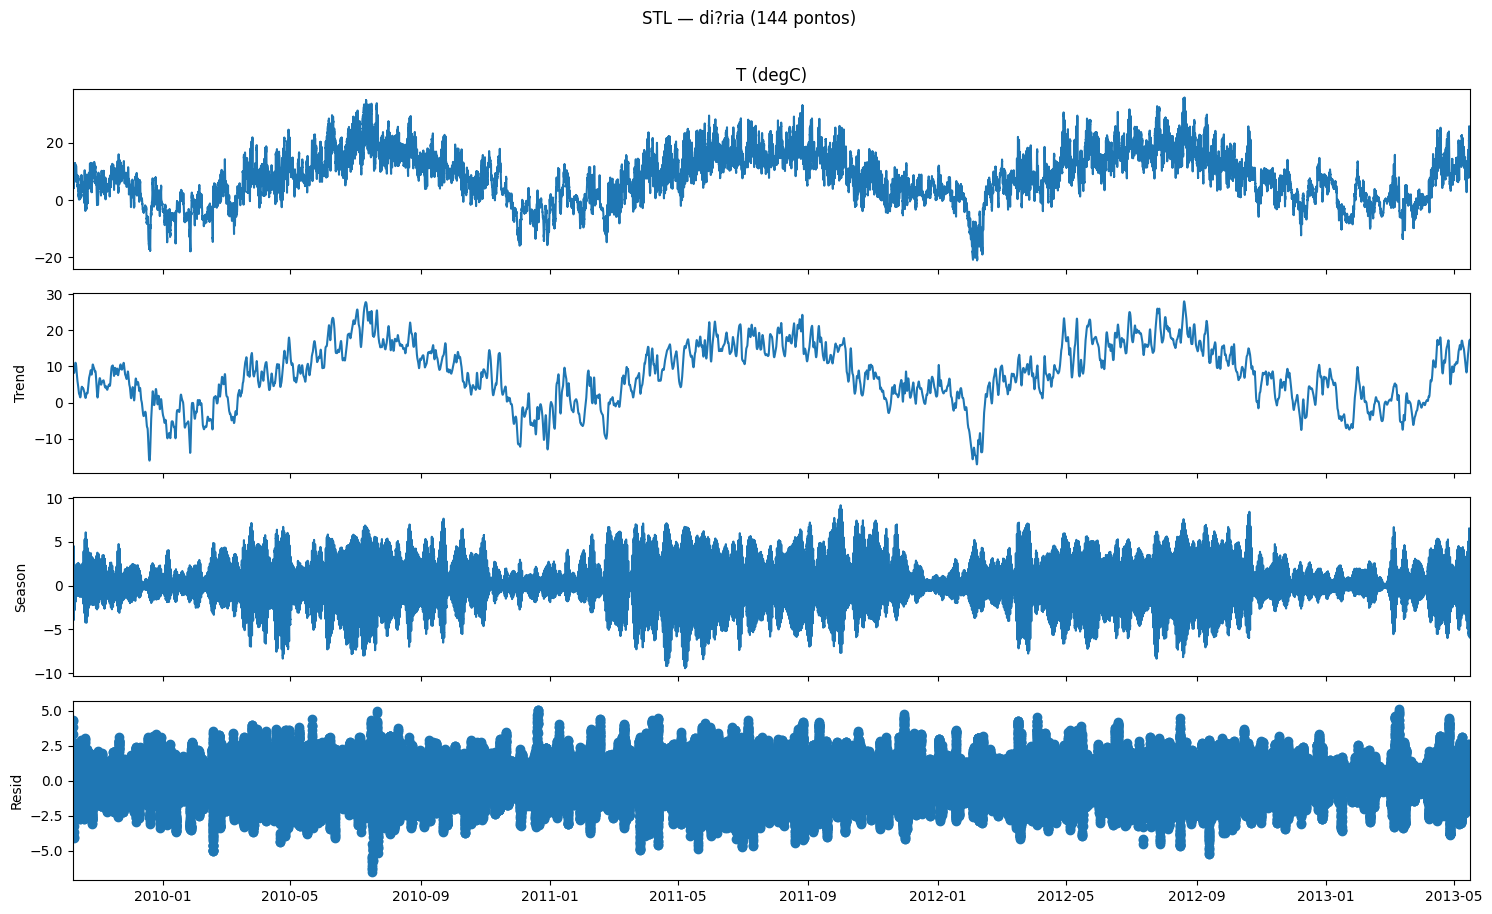

Interpretação: a maior força sazonal foi 0.860 no ciclo di?ria (144 pontos). No componente exibido, a tendência varia 7.872 unidades no período, com crescimento líquido. Oscilações do resíduo representam variação não explicada por tendência e sazonalidade; a leitura de mudanças locais deve ser feita diretamente no gráfico.


In [5]:
split_time = df[TIME_COL].iloc[int(len(df) * TRAIN_RATIO)]
stl_series = df.loc[df[TIME_COL] < split_time, [TIME_COL, TARGET_COL]].set_index(TIME_COL)[TARGET_COL]
stl_series = stl_series.asfreq(FREQUENCY)
missing_for_stl = int(stl_series.isna().sum())
minimum_stl_rows = 2 * max(STL_PERIODS.values())
stl_series = longest_observed_run(stl_series, minimum_stl_rows)
stl_rows, stl_results = [], {}
for label, period in STL_PERIODS.items():
    result = STL(stl_series, period=period, robust=STL_ROBUST).fit()
    stl_results[label] = result
    resid_var = np.var(result.resid, ddof=1)
    seasonal_den = np.var(result.seasonal + result.resid, ddof=1)
    trend_den = np.var(result.trend + result.resid, ddof=1)
    stl_rows.append({
        'periodo': label, 'observacoes_por_ciclo': period,
        'forca_sazonalidade': max(0., 1. - resid_var / seasonal_den),
        'forca_tendencia': max(0., 1. - resid_var / trend_den),
        'ausencias_no_treino_nao_interpoladas': missing_for_stl,
        'pontos_no_trecho_continuo': len(stl_series),
        'inicio_trecho': stl_series.index.min(),
        'fim_trecho': stl_series.index.max(),
    })
stl_strength = pd.DataFrame(stl_rows)
display(stl_strength)
selected_label = list(STL_PERIODS)[0]
selected = stl_results[selected_label]
fig = selected.plot(); fig.set_size_inches(15, 9)
fig.suptitle(f'STL — {selected_label}', y=1.01); plt.tight_layout(); plt.show()
strongest = stl_strength.sort_values('forca_sazonalidade', ascending=False).iloc[0]
trend_change = float(selected.trend.iloc[-1] - selected.trend.iloc[0])
trend_direction = 'crescimento líquido' if trend_change > 0 else 'queda líquida' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: a maior força sazonal foi {strongest.forca_sazonalidade:.3f} '
    f'no ciclo {strongest.periodo}. No componente exibido, a tendência varia '
    f'{abs(trend_change):.3f} unidades no período, com {trend_direction}. '
    'Oscilações do resíduo representam variação não explicada por tendência e sazonalidade; '
    'a leitura de mudanças locais deve ser feita diretamente no gráfico.'
)

## 4. Features e corte temporal

A origem `t` usa o alvo e as medições disponíveis em `t`, lags, janelas
históricas e calendário de `t+1`. Só permanecem pares cuja data-alvo está
exatamente um passo depois da origem. O regressor aprende a variação até
`t+1`; o nível é reconstruído para avaliar MAE na unidade original.

In [6]:
validar_proibidas(EXTERNAL_COLS, PROHIBITED_COLS, BASE_ID)
model_df, feature_columns = build_one_step_frame(
    df, time_col=TIME_COL, target_col=TARGET_COL, external_cols=EXTERNAL_COLS,
    expected_step=EXPECTED_STEP, lags=LAGS, windows=WINDOWS, availability=AVAILABILITY,
)
train_df, test_df = chronological_train_test(model_df, TRAIN_RATIO)
X_train, y_train = train_df[feature_columns], train_df.target_delta
X_test, y_test = test_df[feature_columns], test_df.target_delta
assert train_df.target_time.max() < test_df.origin_time.min()
assert not {'y_true', 'target_delta', 'target_time'}.intersection(feature_columns)
display(pd.DataFrame({
    'recorte': ['treino', 'teste'], 'linhas': [len(train_df), len(test_df)],
    'primeira_origem': [train_df.origin_time.min(), test_df.origin_time.min()],
    'última_origem': [train_df.origin_time.max(), test_df.origin_time.max()],
}))
print(f'{len(feature_columns)} features:', feature_columns)

,recorte,linhas,primeira_origem,última_origem
0,treino,331319,2009-01-08 00:10:00,2015-05-26 13:00:00
1,teste,82830,2015-05-26 13:20:00,2016-12-31 23:50:00


33 features: ['level_t', 'p (mbar)_t', 'Tpot (K)_t', 'Tdew (degC)_t', 'rh (%)_t', 'VPmax (mbar)_t', 'VPact (mbar)_t', 'VPdef (mbar)_t', 'sh (g/kg)_t', 'H2OC (mmol/mol)_t', 'rho (g/m**3)_t', 'wv (m/s)_t', 'max. wv (m/s)_t', 'wd_sin_t', 'wd_cos_t', 'target_lag_1', 'target_lag_2', 'target_lag_6', 'target_lag_12', 'target_lag_144', 'target_lag_1008', 'target_mean_6', 'target_std_6', 'target_mean_144', 'target_std_144', 'target_mean_1008', 'target_std_1008', 'target_hour_sin', 'target_hour_cos', 'target_dow_sin', 'target_dow_cos', 'target_month_sin', 'target_month_cos']


## 5. Otimização temporal do Random Forest

O desenho abaixo investiga `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf` e `max_features` em dobras
expansivas purgadas. A Base 4 limita o tuning às 60 mil linhas de treino
mais recentes por custo; o ajuste final continua usando todo o histórico.

In [7]:
candidates = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': .7},
    {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': .7},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': .7},
]
tuning = train_df.tail(TUNING_MAX_ROWS).reset_index(drop=True) if TUNING_MAX_ROWS else train_df
tuning_X, tuning_y = tuning[feature_columns], tuning.target_delta
cv_splits = purged_time_series_splits(tuning.origin_time, tuning.target_time, n_splits=3)
search_rows = []
search_start = time.perf_counter()
for candidate_id, params in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        fold_start = time.perf_counter()
        model.fit(tuning_X.iloc[fit_idx], tuning_y.iloc[fit_idx])
        prediction = model.predict(tuning_X.iloc[validation_idx])
        fold_seconds.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(tuning_y.iloc[validation_idx], prediction))
    search_rows.append({
        'candidate_id': candidate_id, **params,
        'mean_validation_mae_delta': np.mean(fold_maes),
        'std_validation_mae_delta': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_seconds),
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae_delta', 'std_validation_mae_delta', 'candidate_id']
).reset_index(drop=True)
best_params = {key: search_results.iloc[0][key] for key in candidates[0]}
for key in ('n_estimators', 'min_samples_split', 'min_samples_leaf'):
    best_params[key] = int(best_params[key])
best_params['max_depth'] = None if pd.isna(best_params['max_depth']) else int(best_params['max_depth'])
display(search_results)
print('Melhores parâmetros:', best_params)
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_validation_mae_delta,std_validation_mae_delta,fit_seconds
0,5,100,NaN,2,3,sqrt,0.146187,0.015667,13.970893
1,3,100,12.0,2,1,sqrt,0.146729,0.012790,9.151838
2,7,200,12.0,10,3,0.7,0.149475,0.010837,82.979052
3,4,100,NaN,10,1,sqrt,0.150741,0.009341,15.303556
4,2,200,NaN,2,1,sqrt,0.151439,0.008017,34.086275
5,1,100,NaN,2,1,sqrt,0.152354,0.008666,19.268746
6,8,200,20.0,5,2,0.7,0.156416,0.004405,136.907610
7,6,100,NaN,2,1,0.7,0.162999,0.002159,84.761511


Melhores parâmetros: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Tempo de busca: 397.28 s


## 6. Walk-forward final e importância das features

Os parâmetros escolhidos ficam fixos. O modelo é reajustado periodicamente
em oito blocos por limitação computacional; cada origem ainda recebe uma
previsão fora da amostra com suas features disponíveis. Em cada reajuste,
entram apenas alvos estritamente anteriores à origem. Este cronograma é
provisório e deverá ser igualado aos demais modelos no protocolo final.

,origin_time,target_time,level_t,y_true,target_delta,y_pred_delta_rf,model_refit_origin,training_target_cutoff,y_pred_rf,y_pred_persistencia,residuo_rf,erro_absoluto_rf,erro_quadratico_rf
0,2015-05-26 13:20:00,2015-05-26 13:30:00,10.58,10.86,0.28,0.170367,2015-05-26 13:20:00,2015-05-26 13:10:00,10.750367,10.58,0.109633,0.109633,0.012019
1,2015-05-26 13:30:00,2015-05-26 13:40:00,10.86,11.04,0.18,0.144829,2015-05-26 13:20:00,2015-05-26 13:10:00,11.004829,10.86,0.035171,0.035171,0.001237
2,2015-05-26 13:40:00,2015-05-26 13:50:00,11.04,11.38,0.34,0.058678,2015-05-26 13:20:00,2015-05-26 13:10:00,11.098678,11.04,0.281322,0.281322,0.079142
3,2015-05-26 13:50:00,2015-05-26 14:00:00,11.38,11.78,0.40,0.103196,2015-05-26 13:20:00,2015-05-26 13:10:00,11.483196,11.38,0.296804,0.296804,0.088092
4,2015-05-26 14:00:00,2015-05-26 14:10:00,11.78,12.20,0.42,0.123179,2015-05-26 13:20:00,2015-05-26 13:10:00,11.903179,11.78,0.296821,0.296821,0.088103


,feature,importance_mean,importance_std,grupo
0,target_hour_cos,0.103267,0.002751,historico_do_alvo
1,target_hour_sin,0.077088,0.001078,historico_do_alvo
2,target_std_6,0.066135,0.001372,historico_do_alvo
3,max. wv (m/s)_t,0.041514,0.000430,externa_na_origem
4,target_lag_12,0.040319,0.001045,historico_do_alvo
5,wd_sin_t,0.038455,0.000324,externa_na_origem
6,target_std_144,0.037669,0.000327,historico_do_alvo
7,wv (m/s)_t,0.035671,0.000340,externa_na_origem
8,wd_cos_t,0.033743,0.000405,externa_na_origem
9,rh (%)_t,0.029499,0.000399,externa_na_origem


,grupo,importance_mean
0,estado_atual_ou_calendario,0.024878
1,externa_na_origem,0.381254
2,historico_do_alvo,0.593868


Externas mais importantes (importância nativa, não causal):


,feature,importance_mean,importance_std,grupo
3,max. wv (m/s)_t,0.041514,0.000430,externa_na_origem
5,wd_sin_t,0.038455,0.000324,externa_na_origem
7,wv (m/s)_t,0.035671,0.000340,externa_na_origem
8,wd_cos_t,0.033743,0.000405,externa_na_origem
9,rh (%)_t,0.029499,0.000399,externa_na_origem


Disponibilidade: estas externas são usadas no estado observado da origem t para prever t+1; valores observados em t+1 nunca entram em X.


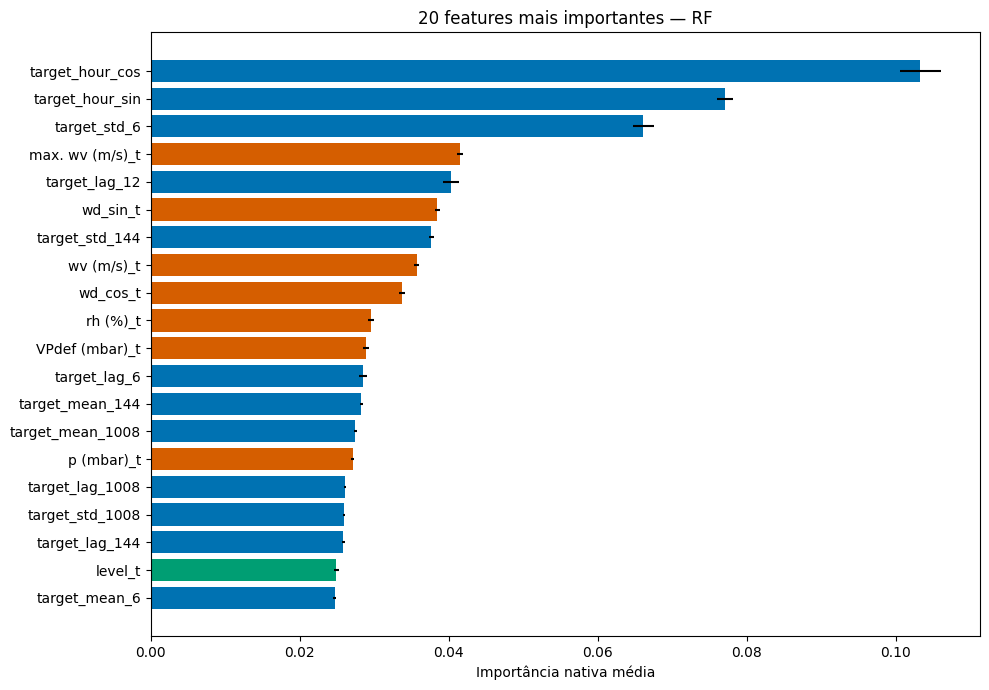

In [8]:
refit_every = max(1, math.ceil(len(test_df) / 8))
predictions_list, prediction_refits, training_cutoffs = [], [], []
fit_rows, importance_rows = [], []
evaluation_start = time.perf_counter()
for block_start in range(0, len(test_df), refit_every):
    block_end = min(block_start + refit_every, len(test_df))
    current_origin = test_df.iloc[block_start].origin_time
    known_test = test_df.target_time < current_origin
    history = pd.concat([train_df, test_df.loc[known_test]], ignore_index=True)
    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    fit_start = time.perf_counter()
    model.fit(history[feature_columns], history.target_delta)
    predictions_list.extend(model.predict(X_test.iloc[block_start:block_end]))
    prediction_refits.extend([current_origin] * (block_end - block_start))
    training_cutoff = history.target_time.max()
    training_cutoffs.extend([training_cutoff] * (block_end - block_start))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_treino': len(history),
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'fit_seconds': time.perf_counter() - fit_start,
    })
    importance_rows.append(model.feature_importances_)
evaluation_seconds = time.perf_counter() - evaluation_start
predictions = test_df[['origin_time', 'target_time', 'level_t', 'y_true', 'target_delta']].copy()
predictions['y_pred_delta_rf'] = np.asarray(predictions_list)
predictions['model_refit_origin'] = prediction_refits
predictions['training_target_cutoff'] = training_cutoffs
assert (predictions.training_target_cutoff < predictions.origin_time).all()
predictions['y_pred_rf'] = predictions.level_t + predictions.y_pred_delta_rf
predictions['y_pred_persistencia'] = predictions.level_t
predictions['residuo_rf'] = predictions.y_true - predictions.y_pred_rf
predictions['erro_absoluto_rf'] = predictions.residuo_rf.abs()
predictions['erro_quadratico_rf'] = predictions.residuo_rf.pow(2)
fit_log = pd.DataFrame(fit_rows)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': np.mean(importance_rows, axis=0),
    'importance_std': np.std(importance_rows, axis=0),
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
external_feature_names = {f'{column}_t' for column in EXTERNAL_COLS}
feature_importance['grupo'] = np.select(
    [feature_importance.feature.isin(external_feature_names),
     feature_importance.feature.str.startswith('target_')],
    ['externa_na_origem', 'historico_do_alvo'], default='estado_atual_ou_calendario',
)
display(predictions.head())
display(feature_importance.head(20))
display(feature_importance.groupby('grupo', as_index=False).importance_mean.sum())
top_external = feature_importance.loc[
    feature_importance.grupo.eq('externa_na_origem')
].head(5)
print('Externas mais importantes (importância nativa, não causal):')
display(top_external)
print(
    'Disponibilidade: estas externas são usadas no estado observado da origem t '
    'para prever t+1; valores observados em t+1 nunca entram em X.'
)
colors = feature_importance.head(20).grupo.map({
    'externa_na_origem': '#d55e00', 'historico_do_alvo': '#0072b2',
    'estado_atual_ou_calendario': '#009e73',
})
top = feature_importance.head(20).sort_values('importance_mean')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.feature, top.importance_mean, xerr=top.importance_std,
        color=colors.loc[top.index])
ax.set(title='20 features mais importantes — RF', xlabel='Importância nativa média')
plt.tight_layout(); plt.show()

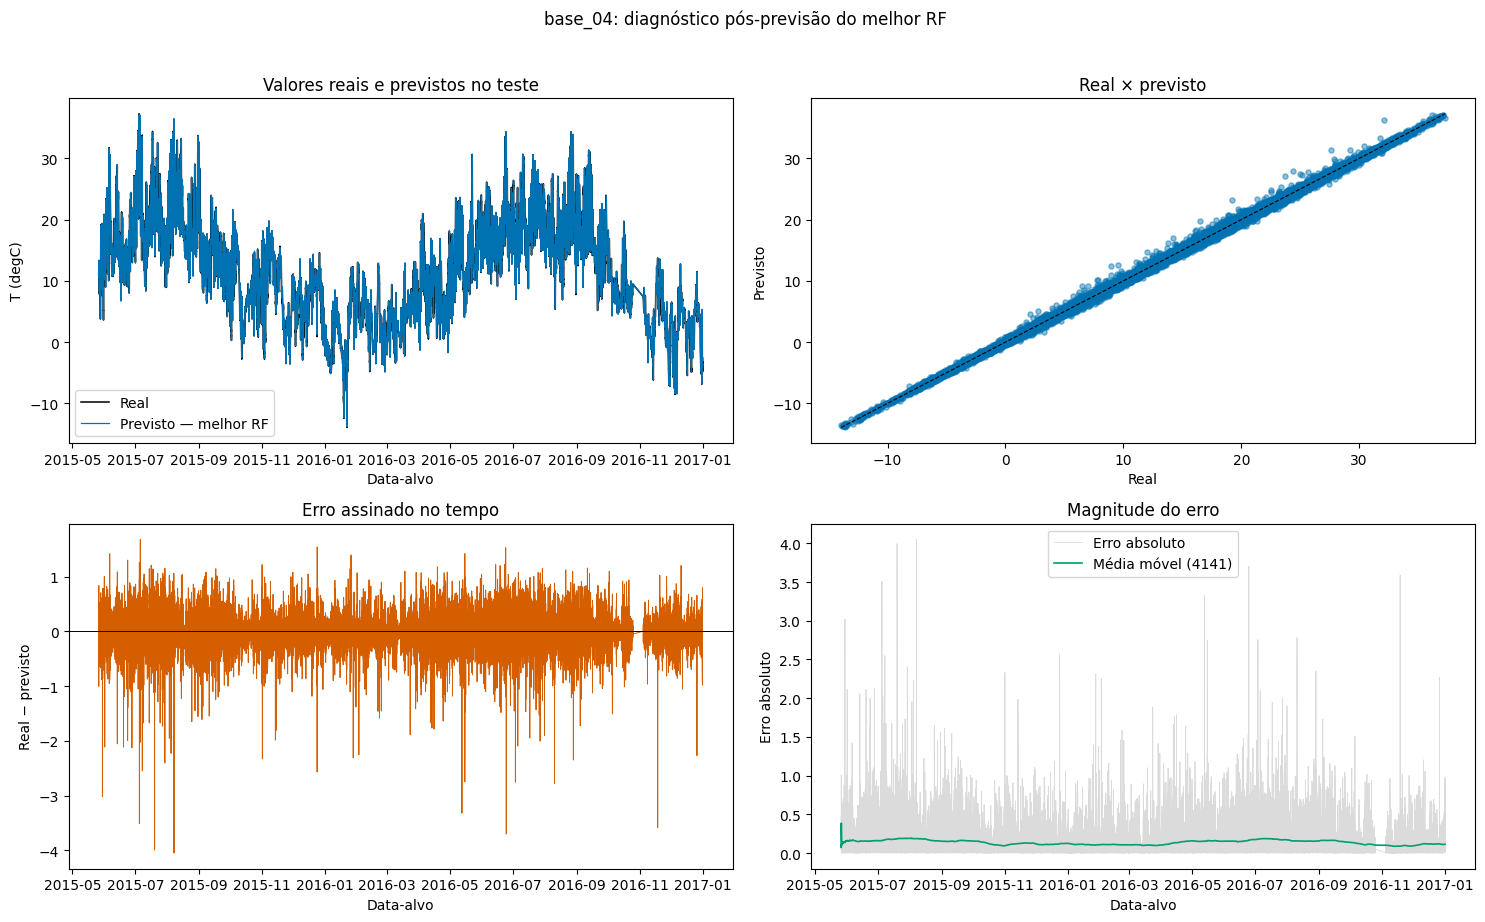

In [9]:
# Diagnóstico visual fora da amostra do melhor Random Forest
diagnostic_window = max(5, len(predictions) // 20)
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(predictions.target_time, predictions.y_true, label='Real', color='black', lw=1.1)
axes[0, 0].plot(predictions.target_time, predictions.y_pred_rf, label='Previsto — melhor RF', color='#0072b2', lw=.9)
axes[0, 0].set(title='Valores reais e previstos no teste', xlabel='Data-alvo', ylabel=TARGET_COL)
axes[0, 0].legend()

plot_limits = [predictions[['y_true', 'y_pred_rf']].min().min(), predictions[['y_true', 'y_pred_rf']].max().max()]
axes[0, 1].scatter(predictions.y_true, predictions.y_pred_rf, s=14, alpha=.45, color='#0072b2')
axes[0, 1].plot(plot_limits, plot_limits, '--', color='black', lw=.8)
axes[0, 1].set(title='Real × previsto', xlabel='Real', ylabel='Previsto')

axes[1, 0].plot(predictions.target_time, predictions.residuo_rf, color='#d55e00', lw=.7)
axes[1, 0].axhline(0, color='black', lw=.7)
axes[1, 0].set(title='Erro assinado no tempo', xlabel='Data-alvo', ylabel='Real − previsto')

axes[1, 1].plot(predictions.target_time, predictions.erro_absoluto_rf, color='#999999', alpha=.35, lw=.6, label='Erro absoluto')
axes[1, 1].plot(predictions.target_time, predictions.erro_absoluto_rf.rolling(diagnostic_window, min_periods=1).mean(), color='#009e73', lw=1.2, label=f'Média móvel ({diagnostic_window})')
axes[1, 1].set(title='Magnitude do erro', xlabel='Data-alvo', ylabel='Erro absoluto')
axes[1, 1].legend()

fig.suptitle(f'{BASE_ID}: diagnóstico pós-previsão do melhor RF', y=1.02)
plt.tight_layout(); plt.show()

## . MAE e demais métricas

O MAE principal é calculado fora da amostra no nível e na unidade original.
A persistência (`ŷ(t+1)=y(t)`) torna explícito se o RF agrega valor.

In [10]:
def metric_row(name, values):
    values = np.asarray(values)
    return {
        'modelo': name,
        'MAE': mean_absolute_error(predictions.y_true, values),
        'RMSE': mean_squared_error(predictions.y_true, values) ** .5,
        'MedAE': median_absolute_error(predictions.y_true, values),
        'R2': r2_score(predictions.y_true, values),
        'vies_medio': np.mean(predictions.y_true - values),
    }
metrics = pd.DataFrame([
    metric_row('Random Forest', predictions.y_pred_rf),
    metric_row('Persistência', predictions.y_pred_persistencia),
])
display(metrics)

,modelo,MAE,RMSE,MedAE,R2,vies_medio
0,Random Forest,0.136593,0.209119,0.088169,0.999339,0.006997
1,Persistência,0.166198,0.249848,0.110000,0.999057,-0.000183


## 8. Registro de parâmetros, versões e tempo

In [11]:
experiment_record = pd.DataFrame([{
    'base': 'Base 4 — temperatura em Jena',
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'frequencia': FREQUENCY, 'alvo_original': TARGET_COL,
    'alvo_modelo': 'delta de um passo', 'horizonte_provisorio': str(EXPECTED_STEP),
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino': len(train_df), 'linhas_teste': len(test_df),
    'origem_teste_inicial': test_df.origin_time.min(),
    'origem_teste_final': test_df.origin_time.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'linhas_usadas_tuning': len(tuning),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 4 — temperatura em Jena
arquivo,data\base_04\prepared.csv
sha256,4e3a2361cd6c686a68162e57baa1907466a59866a4026d...
frequencia,10min
alvo_original,T (degC)
alvo_modelo,delta de um passo
horizonte_provisorio,0 days 00:10:00
split_treino,0.8
random_state,42
linhas_treino,331319


,origem_refit,linhas_treino,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2015-05-26 13:20:00,331319,0,10354,92.779095
1,2015-08-06 14:20:00,341672,10354,20708,77.240236
2,2015-10-17 12:00:00,352026,20708,31062,59.637080
3,2015-12-28 09:40:00,362380,31062,41416,69.632494
4,2016-03-09 07:20:00,372734,41416,51770,85.483610
5,2016-05-20 05:00:00,383088,51770,62124,103.891223
6,2016-07-31 02:40:00,393442,62124,72478,92.361851
7,2016-10-11 00:20:00,403796,72478,82830,75.166550


## 9. Resíduos individuais

Cada origem do teste possui previsão, resíduo e erros individuais. O gráfico
permite verificar viés, mudanças de dispersão e períodos de deterioração.

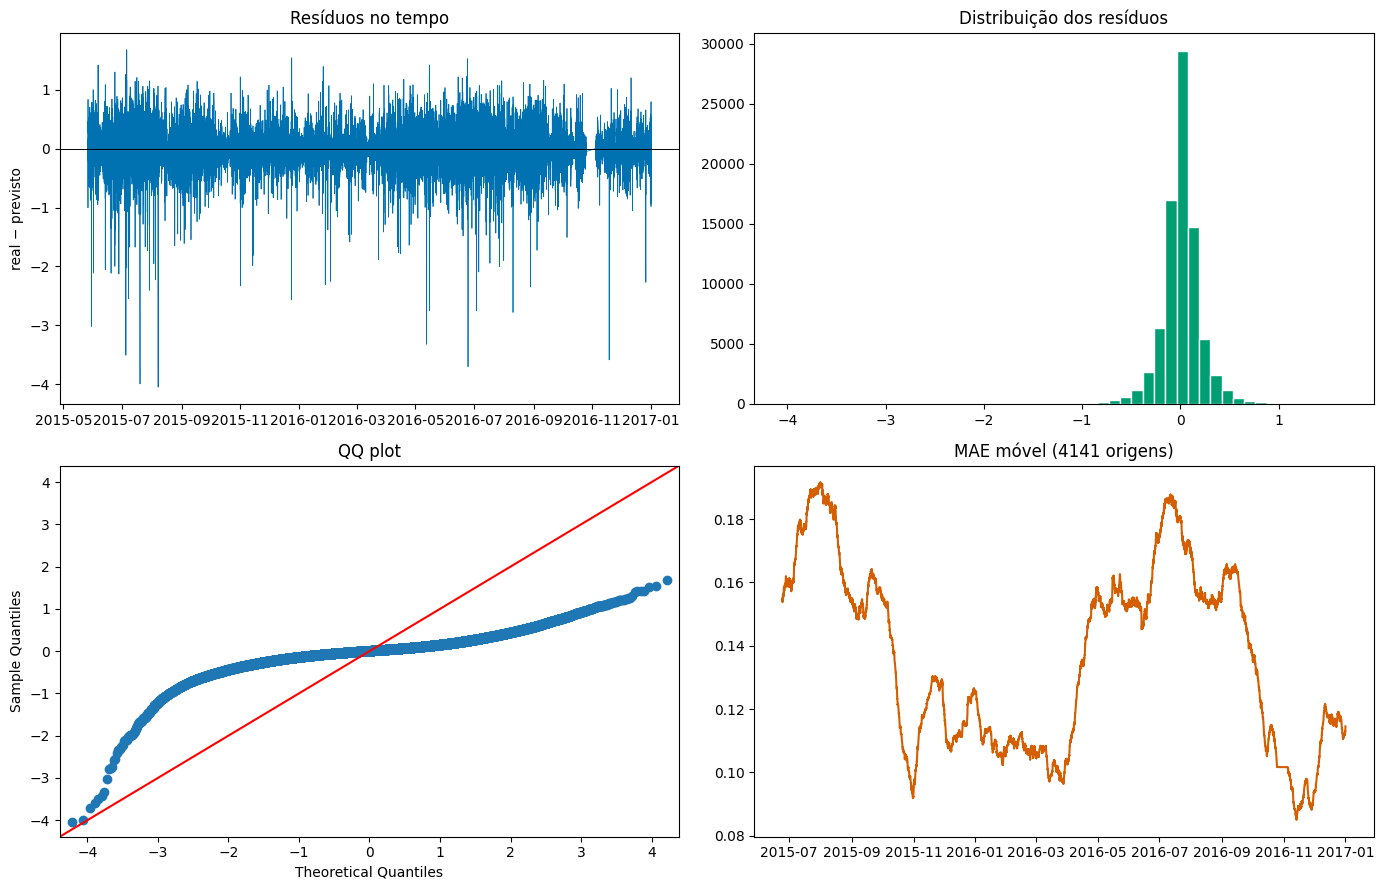

,origin_time,target_time,level_t,y_true,target_delta,y_pred_delta_rf,model_refit_origin,training_target_cutoff,y_pred_rf,y_pred_persistencia,residuo_rf,erro_absoluto_rf,erro_quadratico_rf
0,2015-05-26 13:20:00,2015-05-26 13:30:00,10.58,10.86,0.28,0.170367,2015-05-26 13:20:00,2015-05-26 13:10:00,10.750367,10.58,0.109633,0.109633,0.012019
1,2015-05-26 13:30:00,2015-05-26 13:40:00,10.86,11.04,0.18,0.144829,2015-05-26 13:20:00,2015-05-26 13:10:00,11.004829,10.86,0.035171,0.035171,0.001237
2,2015-05-26 13:40:00,2015-05-26 13:50:00,11.04,11.38,0.34,0.058678,2015-05-26 13:20:00,2015-05-26 13:10:00,11.098678,11.04,0.281322,0.281322,0.079142
3,2015-05-26 13:50:00,2015-05-26 14:00:00,11.38,11.78,0.40,0.103196,2015-05-26 13:20:00,2015-05-26 13:10:00,11.483196,11.38,0.296804,0.296804,0.088092
4,2015-05-26 14:00:00,2015-05-26 14:10:00,11.78,12.20,0.42,0.123179,2015-05-26 13:20:00,2015-05-26 13:10:00,11.903179,11.78,0.296821,0.296821,0.088103
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82825,2016-12-31 23:10:00,2016-12-31 23:20:00,-3.93,-4.05,-0.12,-0.097497,2016-10-11 00:20:00,2016-10-11 00:10:00,-4.027497,-3.93,-0.022503,0.022503,0.000506
82826,2016-12-31 23:20:00,2016-12-31 23:30:00,-4.05,-3.35,0.70,-0.096148,2016-10-11 00:20:00,2016-10-11 00:10:00,-4.146148,-4.05,0.796148,0.796148,0.633852
82827,2016-12-31 23:30:00,2016-12-31 23:40:00,-3.35,-3.16,0.19,-0.080593,2016-10-11 00:20:00,2016-10-11 00:10:00,-3.430593,-3.35,0.270593,0.270593,0.073220
82828,2016-12-31 23:40:00,2016-12-31 23:50:00,-3.16,-4.23,-1.07,-0.086795,2016-10-11 00:20:00,2016-10-11 00:10:00,-3.246795,-3.16,-0.983205,0.983205,0.966693


In [12]:
residuals = predictions.residuo_rf
rolling_window = max(5, len(predictions) // 20)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(predictions.target_time, residuals, lw=.55, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=50, edgecolor='white', color='#009e73')
axes[0, 1].set(title='Distribuição dos resíduos')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(predictions.target_time, predictions.erro_absoluto_rf.rolling(rolling_window).mean(), color='#d55e00')
axes[1, 1].set(title=f'MAE móvel ({rolling_window} origens)')
plt.tight_layout(); plt.show()
display(predictions)

## 11. ACF dos resíduos e Ljung–Box

A ACF inspeciona dependência residual. O Ljung–Box testa conjuntamente a
hipótese de ausência de autocorrelação até cada lag informado.

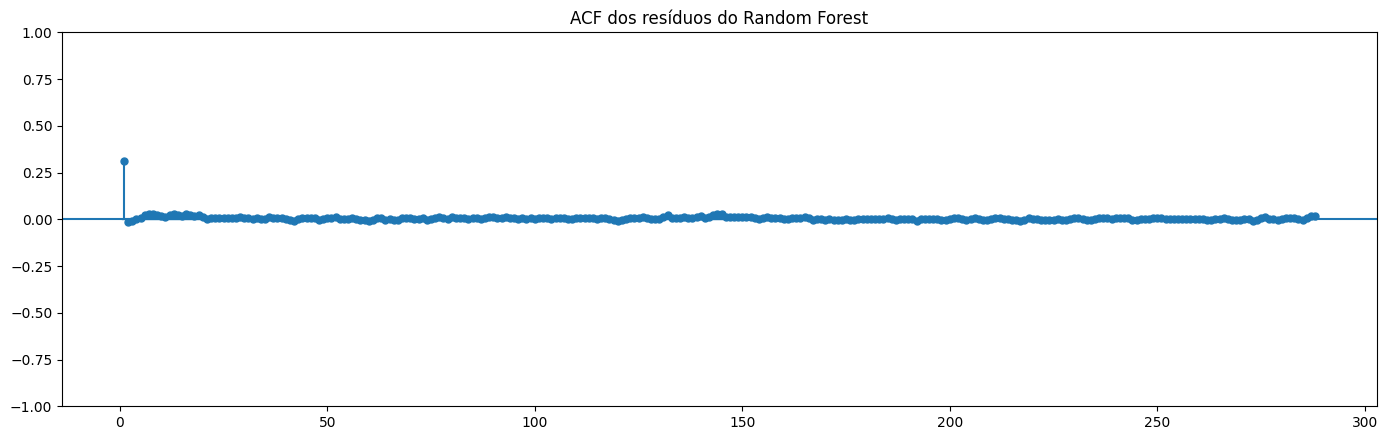

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,8005.413251,0.0,True
6,8062.299943,0.0,True
144,9224.156152,0.0,True
288,9643.378512,0.0,True


In [13]:
usable_acf_lags = min(ACF_LAGS, max(1, len(residuals) // 2 - 1))
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=usable_acf_lags, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do Random Forest')
plt.tight_layout(); plt.show()
usable_ljung_lags = sorted({lag for lag in LJUNG_LAGS if lag < len(residuals)})
ljung_box = acorr_ljungbox(residuals, lags=usable_ljung_lags, return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)